# Logistic Regression Classification Analysis for Heart Disease Prediction
**Machine Learning Assignment — Member 1**  
**Algorithm: Logistic Regression (Binary Classification)**

---

In [97]:
# Library imports for data handling, modeling, and visualization
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

## Data Loading and Parsing
Load the heart dataset, inspect dimensions, and define a binary disease target.

In [98]:
# Load the dataset from the project data folder
data_path = Path("../data/heart_disease_uci.csv")
df = pd.read_csv(data_path)

# Convert diagnosis into binary target: 0=no disease, 1=disease
y = (df["num"] > 0).astype(int)
X = df.drop(columns=["num", "id", "dataset"])

print("Dataset shape:", df.shape)
print("Feature matrix shape:", X.shape)
print("Class distribution:\n", y.value_counts())

Dataset shape: (920, 16)
Feature matrix shape: (920, 13)
Class distribution:
 num
1    509
0    411
Name: count, dtype: int64


## Data Cleaning and Preprocessing
Split the data with stratification and build preprocessing pipelines for numeric and categorical features.

In [99]:
# Split data while preserving class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Identify numeric and categorical columns
num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

# Numeric preprocessing: median imputation + scaling
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

# Categorical preprocessing: mode imputation + one-hot encoding
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

# Apply each preprocessing pipeline to its column group
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, num_features),
    ("cat", categorical_pipeline, cat_features),
])

## Model Training and Baseline Evaluation
Train a baseline logistic regression model and evaluate key classification metrics.

In [100]:
# Evaluation helper: prints metrics and returns predictions/probabilities
def evaluate_model(model, X_eval, y_eval, title):
    y_pred = model.predict(X_eval)
    y_prob = model.predict_proba(X_eval)[:, 1]

    metrics = {
        "acc": accuracy_score(y_eval, y_pred),
        "prec": precision_score(y_eval, y_pred, zero_division=0),
        "rec": recall_score(y_eval, y_pred, zero_division=0),
        "f1": f1_score(y_eval, y_pred, zero_division=0),
        "auc": roc_auc_score(y_eval, y_prob),
    }

    print(title)
    print(f"Accuracy : {metrics['acc']:.4f}")
    print(f"Precision: {metrics['prec']:.4f}")
    print(f"Recall   : {metrics['rec']:.4f}")
    print(f"F1-score : {metrics['f1']:.4f}")
    print(f"ROC-AUC  : {metrics['auc']:.4f}")

    print("\nConfusion Matrix:\n", confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:\n", classification_report(y_eval, y_pred, zero_division=0))

    return y_pred, y_prob, metrics

# Baseline logistic regression model
baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42)),
])

baseline_model.fit(X_train, y_train)
base_pred, base_prob, baseline_metrics = evaluate_model(
    baseline_model,
    X_test,
    y_test,
    "Baseline Logistic Regression Results",
)

Baseline Logistic Regression Results
Accuracy : 0.8424
Precision: 0.8411
Recall   : 0.8824
F1-score : 0.8612
ROC-AUC  : 0.9035

Confusion Matrix:
 [[65 17]
 [12 90]]

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.79      0.82        82
           1       0.84      0.88      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.84      0.84       184
weighted avg       0.84      0.84      0.84       184



## Hyperparameter Tuning
Use GridSearchCV with stratified folds to optimize F1 while keeping robust ROC-AUC performance.

In [101]:
# Hyperparameter search space
param_grid = {
    "model__solver": ["liblinear", "lbfgs"],
    "model__C": [0.01, 0.1, 1, 10, 50],
    "model__class_weight": [None, "balanced"],
}

# Stratified CV keeps class ratios consistent in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=baseline_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    error_score="raise",
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'model__C': 1, 'model__class_weight': None, 'model__solver': 'liblinear'}
Best CV F1: 0.8324


In [102]:
# Second tuning run with balanced class weighting
final_param_grid = {
    "model__solver": ["liblinear", "saga"],
    "model__C": [0.01, 0.1, 10, 50],
    "model__class_weight": ["balanced"],
}

final_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
final_grid = GridSearchCV(
    estimator=baseline_model,
    param_grid=final_param_grid,
    scoring="f1",
    cv=final_cv,
    n_jobs=-1,
    verbose=0,
    error_score="raise",
)

final_grid.fit(X_train, y_train)
best_model = final_grid.best_estimator_

# Evaluate tuned model on the holdout test set
best_pred, best_prob, tuned_metrics = evaluate_model(
    best_model,
    X_test,
    y_test,
    "Tuned Logistic Regression Results",
)

# Compare baseline and tuned metrics
summary_df = pd.DataFrame([
    {"model": "baseline", **baseline_metrics},
    {"model": "tuned", **tuned_metrics},
]).set_index("model")

print("\nLogistic Regression Summary Table:")
print(summary_df.round(4))

Tuned Logistic Regression Results
Accuracy : 0.8370
Precision: 0.8462
Recall   : 0.8627
F1-score : 0.8544
ROC-AUC  : 0.9024

Confusion Matrix:
 [[66 16]
 [14 88]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.80      0.81        82
           1       0.85      0.86      0.85       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184


Logistic Regression Summary Table:
             acc    prec     rec      f1     auc
model                                           
baseline  0.8424  0.8411  0.8824  0.8612  0.9035
tuned     0.8370  0.8462  0.8627  0.8544  0.9024


In [103]:
# Threshold analysis
thresholds = [0.30, 0.40, 0.50, 0.60, 0.70]
threshold_metrics = []

for t in thresholds:
    t_pred = (best_prob >= t).astype(int)
    threshold_metrics.append({
        "threshold": t,
        "precision": precision_score(y_test, t_pred, zero_division=0),
        "recall": recall_score(y_test, t_pred, zero_division=0),
        "f1": f1_score(y_test, t_pred, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_metrics)
print("Threshold Tuning Table:")
print(threshold_df.round(4))

best_f1_row = threshold_df.loc[threshold_df["f1"].idxmax()]
print(
    f"\nRecommended threshold (max F1): {best_f1_row['threshold']:.2f} "
    f"with F1={best_f1_row['f1']:.4f}"
)

Threshold Tuning Table:
   threshold  precision  recall      f1
0        0.3     0.7705  0.9216  0.8393
1        0.4     0.8198  0.8922  0.8545
2        0.5     0.8462  0.8627  0.8544
3        0.6     0.8617  0.7941  0.8265
4        0.7     0.9200  0.6765  0.7797

Recommended threshold (max F1): 0.40 with F1=0.8545


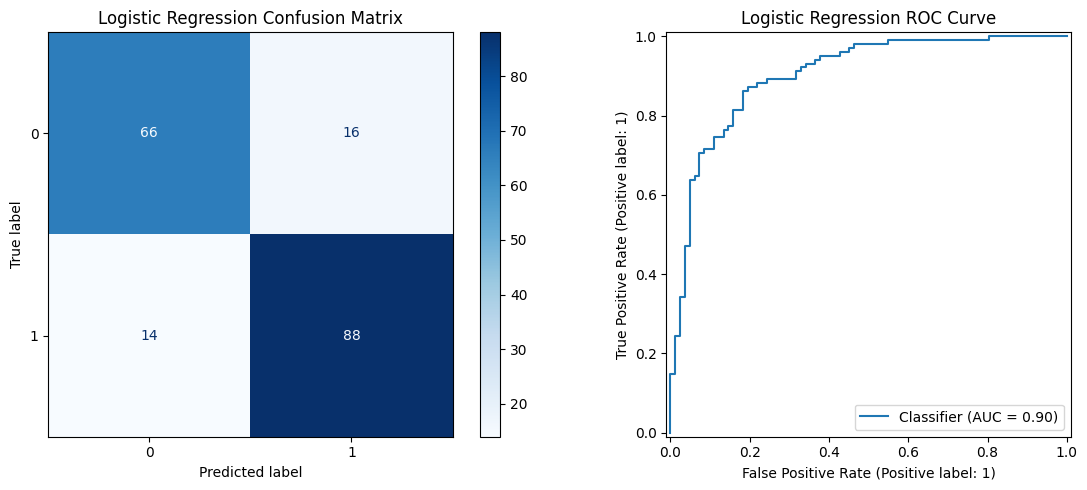

In [104]:
# Visual diagnostics for tuned model
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=axes[0], cmap="Blues")
axes[0].set_title("Logistic Regression Confusion Matrix")
RocCurveDisplay.from_predictions(y_test, best_prob, ax=axes[1])
axes[1].set_title("Logistic Regression ROC Curve")
plt.tight_layout()
plt.show()

## Patient-Level Prediction Example
Run inference for one patient sample and interpret the predicted disease probability.

In [105]:
# Single-patient inference example
sample_patient = pd.DataFrame([{
    "age": 20,
    "sex": "Male",
    "cp": "asymptomatic",
    "trestbps": 140,
    "chol": 129,
    "fbs": "FALSE",
    "restecg": "normal",
    "thalch": 160,
    "exang": "FALSE",
    "oldpeak": 1.2,
    "slope": "flat",
    "ca": 0,
    "thal": "normal",
}])

sample_pred = best_model.predict(sample_patient)[0]
sample_prob = best_model.predict_proba(sample_patient)[0, 1]

print("Predicted class (0=no disease, 1=disease):", int(sample_pred))
print("Predicted disease probability:", round(float(sample_prob), 4))
print("Interpretation: This patient has a {:.2%} chance of heart disease.".format(sample_prob))
print("Model Accuracy on Test Set: {:.2%}".format(tuned_metrics["acc"]))

Predicted class (0=no disease, 1=disease): 1
Predicted disease probability: 0.5524
Interpretation: This patient has a 55.24% chance of heart disease.
Model Accuracy on Test Set: 83.70%
